In [16]:
   from google.colab import files

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
# Define hyperparameters
EPOCHS = 100
BATCH_SIZE = 64

In [7]:
# Helper function to load data per window size

def load_window_data(window_size):
    X_train = np.load(f'X_train_w{window_size}.npy')
    y_train = np.load(f'y_train_w{window_size}.npy')
    X_val   = np.load(f'X_val_w{window_size}.npy')
    y_val   = np.load(f'y_val_w{window_size}.npy')
    return X_train, y_train, X_val, y_val

In [8]:
# Train window=24 (test run first)

window_size = 24
X_train, y_train, X_val, y_val = load_window_data(window_size)
model = keras.models.load_model(f'lstm_model_w{window_size}_untrained.keras')

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(f'best_lstm_w{window_size}.keras', monitor='val_loss', save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1287/1287 ━━━━━━━━━━━━━━━━━━━━ 51s 37ms/step - loss: 0.3022 - mae: 0.3238 - val_loss: 0.1633 - val_mae: 0.2095 - learning_rate: 0.0010
Epoch 2/100
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 46s 36ms/step - loss: 0.2714 - mae: 0.2896 - val_loss: 0.1559 - val_mae: 0.1918 - learning_rate: 0.0010
Epoch 3/100
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - loss: 0.2630 - mae: 0.2800 - val_loss: 0.1559 - val_mae: 0.1979 - learning_rate: 0.0010
Epoch 4/100
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - loss: 0.2574 - mae: 0.2747 - val_loss: 0.1601 - val_mae: 0.1928 - learning_rate: 0.0010
Epoch 5/100
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - loss: 0.2538 - mae: 0.2712 - val_loss: 0.1674 - val_mae: 0.1996 - learning_rate: 0.0010
Epoch 6/100
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - loss: 0.2461 - mae: 0.2641 - val_loss: 0.1734 - val_mae: 0.2028 - learning_rate: 5.0000e-04
Epoch 7/100
1287/1287 ━━━━━━━━━━━━━━━━━━━━ 45s 35ms/step - loss: 0.2429 - mae: 0.2612 - val_loss: 0.1725 - val_mae: 0.1983 - l

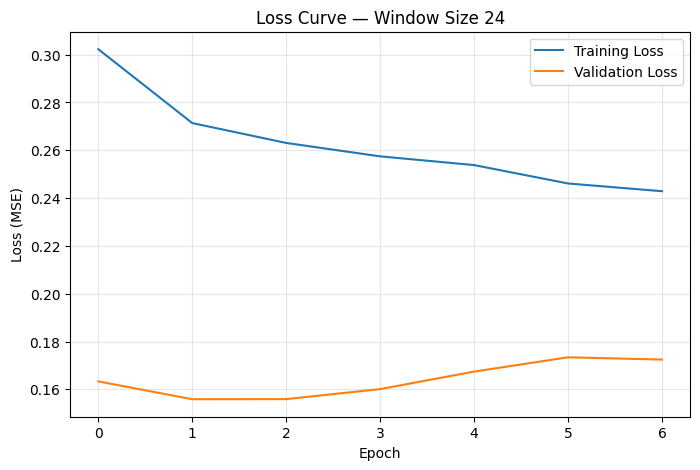

In [9]:
# Plot loss curve function + plot it
def plot_loss_curve(history, window_size):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Curve — Window Size {window_size}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'loss_curve_w{window_size}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_loss_curve(history, window_size)


=== Training window size 32 ===
Epoch 1/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 60s 46ms/step - loss: 0.3167 - mae: 0.3334 - val_loss: 0.1663 - val_mae: 0.2023 - learning_rate: 0.0010
Epoch 2/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - loss: 0.2827 - mae: 0.2976 - val_loss: 0.1589 - val_mae: 0.2028 - learning_rate: 0.0010
Epoch 3/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - loss: 0.2745 - mae: 0.2888 - val_loss: 0.1564 - val_mae: 0.1794 - learning_rate: 0.0010
Epoch 4/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 84s 48ms/step - loss: 0.2715 - mae: 0.2838 - val_loss: 0.1597 - val_mae: 0.1989 - learning_rate: 0.0010
Epoch 5/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 59s 48ms/step - loss: 0.2637 - mae: 0.2778 - val_loss: 0.1609 - val_mae: 0.1875 - learning_rate: 0.0010
Epoch 6/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 59s 48ms/step - loss: 0.2587 - mae: 0.2734 - val_loss: 0.1581 - val_mae: 0.1879 - learning_rate: 0.0010
Epoch 7/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - loss: 0.2526 - mae: 0.2670

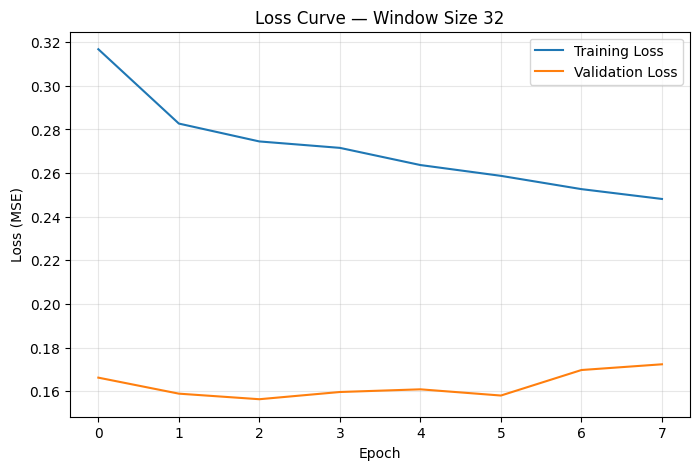


=== Training window size 48 ===
Epoch 1/100
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - loss: 0.3252 - mae: 0.3395 - val_loss: 0.1813 - val_mae: 0.2053 - learning_rate: 0.0010
Epoch 2/100
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - loss: 0.2926 - mae: 0.3030 - val_loss: 0.1575 - val_mae: 0.1947 - learning_rate: 0.0010
Epoch 3/100
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 80s 71ms/step - loss: 0.2818 - mae: 0.2925 - val_loss: 0.1547 - val_mae: 0.1880 - learning_rate: 0.0010
Epoch 4/100
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 75s 67ms/step - loss: 0.2772 - mae: 0.2873 - val_loss: 0.1551 - val_mae: 0.1870 - learning_rate: 0.0010
Epoch 5/100
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 77s 68ms/step - loss: 0.2725 - mae: 0.2831 - val_loss: 0.1596 - val_mae: 0.1907 - learning_rate: 0.0010
Epoch 6/100
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 75s 66ms/step - loss: 0.2674 - mae: 0.2799 - val_loss: 0.1710 - val_mae: 0.1867 - learning_rate: 0.0010
Epoch 7/100
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 78s 69ms/step - loss: 0.2621 - mae: 0.2742

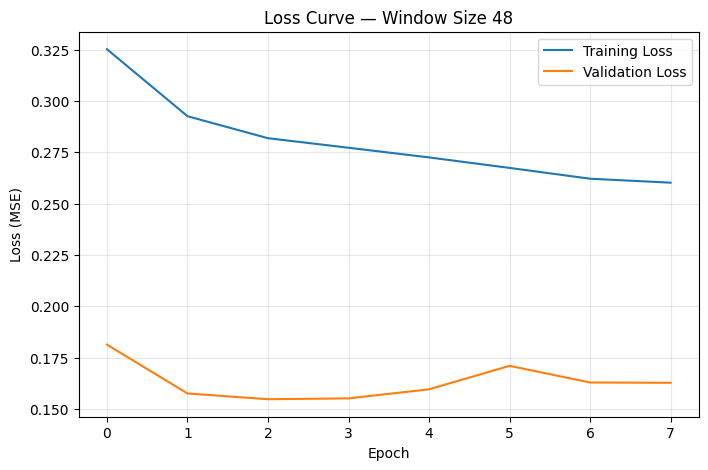

In [10]:
# Train window=32 and window=48, storing all results
results = {24: {'history': history, 'best_val_loss': min(history.history['val_loss'])}}

for window_size in [32, 48]:
    X_train, y_train, X_val, y_val = load_window_data(window_size)
    model = keras.models.load_model(f'lstm_model_w{window_size}_untrained.keras')

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(f'best_lstm_w{window_size}.keras', monitor='val_loss', save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]

    print(f"\n=== Training window size {window_size} ===")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    plot_loss_curve(history, window_size)
    results[window_size] = {'history': history, 'best_val_loss': min(history.history['val_loss'])}

In [11]:
# Compare all 3 and pick the best window size
print("=== Final Comparison ===")
for w, r in results.items():
    print(f"Window size {w}: best validation loss (MSE) = {r['best_val_loss']:.5f}")

best_window = min(results, key=lambda w: results[w]['best_val_loss'])
print(f"\nBest performing window size: {best_window}")

=== Final Comparison ===
Window size 24: best validation loss (MSE) = 0.15588
Window size 32: best validation loss (MSE) = 0.15637
Window size 48: best validation loss (MSE) = 0.15472

Best performing window size: 48


In [18]:
# Download everything
for window_size in [24, 32, 48]:
    files.download(f'best_lstm_w{window_size}.keras')
    files.download(f'loss_curve_w{window_size}.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>